N= 2, τ=0.010, ergotropy = 1.999400, variance = 0.000600
N= 4, τ=0.010, ergotropy = 3.998000, variance = 0.002000
N= 6, τ=0.010, ergotropy = 5.995800, variance = 0.004201
N= 8, τ=0.010, ergotropy = 7.992800, variance = 0.007202
N=10, τ=0.010, ergotropy = 9.989000, variance = 0.011006
N=12, τ=0.010, ergotropy = 11.984400, variance = 0.015611
N=14, τ=0.010, ergotropy = 13.979000, variance = 0.021019
N=16, τ=0.010, ergotropy = 15.972800, variance = 0.027230
N=18, τ=0.010, ergotropy = 17.965800, variance = 0.034245
N=20, τ=0.010, ergotropy = 19.958000, variance = 0.042063
N=22, τ=0.010, ergotropy = 21.949400, variance = 0.050686
N=24, τ=0.010, ergotropy = 23.940000, variance = 0.060114
N=26, τ=0.010, ergotropy = 25.929800, variance = 0.070347
N=28, τ=0.010, ergotropy = 27.918800, variance = 0.081386
N=30, τ=0.010, ergotropy = 29.907000, variance = 0.093232
N=32, τ=0.010, ergotropy = 31.894400, variance = 0.105884
N=34, τ=0.010, ergotropy = 33.881000, variance = 0.119343
N=36, τ=0.010, ergo

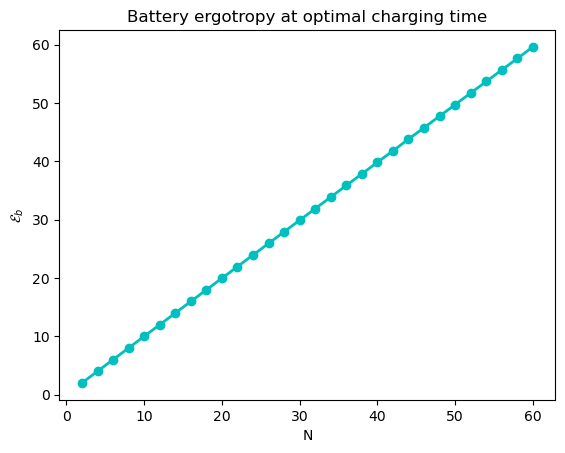

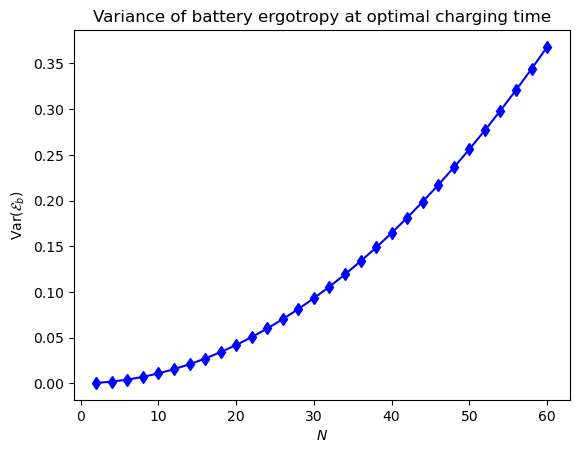

In [40]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 62, 2)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.1)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, 0)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].proj().ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
    
    r_vecs = np.sort(rho_b.eigenenergies())[::-1]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].conj().T for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(E_erg / E_B)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, ergotropy = {E_ergo[idx]:.6f}, variance = {E_var[idx]:.6f}")

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

N= 2, τ=0.010, Erg / <EB>=1.000000
N= 4, τ=0.010, Erg / <EB>=1.000000
N= 6, τ=0.010, Erg / <EB>=1.000000
N= 8, τ=0.010, Erg / <EB>=1.000000
N=10, τ=0.010, Erg / <EB>=1.000000
N=12, τ=0.010, Erg / <EB>=1.000000
N=14, τ=0.010, Erg / <EB>=1.000000
N=16, τ=0.010, Erg / <EB>=1.000000
N=18, τ=0.010, Erg / <EB>=1.000000
N=20, τ=0.010, Erg / <EB>=1.000000
N=22, τ=0.010, Erg / <EB>=1.000000
N=24, τ=0.010, Erg / <EB>=1.000000
N=26, τ=0.010, Erg / <EB>=1.000000
N=28, τ=0.010, Erg / <EB>=1.000000
N=30, τ=0.010, Erg / <EB>=1.000000
N=32, τ=0.010, Erg / <EB>=1.000000
N=34, τ=0.010, Erg / <EB>=1.000000
N=36, τ=0.010, Erg / <EB>=1.000000
N=38, τ=0.010, Erg / <EB>=1.000000
N=40, τ=0.010, Erg / <EB>=1.000000
N=42, τ=0.010, Erg / <EB>=1.000000
N=44, τ=0.010, Erg / <EB>=1.000000
N=46, τ=0.010, Erg / <EB>=1.000000
N=48, τ=0.010, Erg / <EB>=1.000000
N=50, τ=0.010, Erg / <EB>=1.000000
N=52, τ=0.010, Erg / <EB>=0.999999
N=54, τ=0.010, Erg / <EB>=0.999999
N=56, τ=0.010, Erg / <EB>=0.999999
N=58, τ=0.010, Erg /

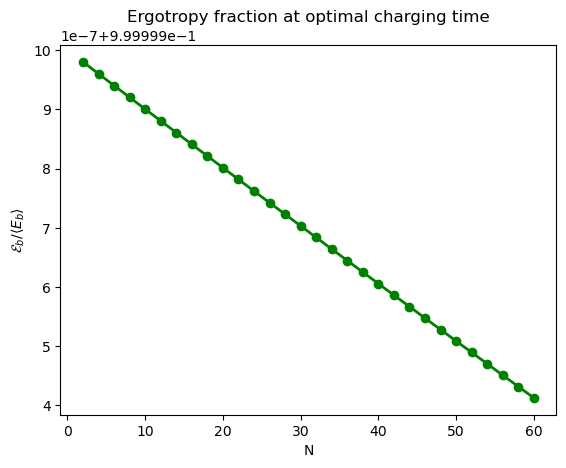

In [41]:
##########################################################
# Plot ergotropy fraction as function of g for different N 
##########################################################
    
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Erg / <EB>={E_ratio[idx]:.6f}")

plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.010, Relative Fluctuation =0.012250, Relative Fluctuation with Eb =0.012250
N= 4, τ=0.010, Relative Fluctuation =0.011186, Relative Fluctuation with Eb =0.011186
N= 6, τ=0.010, Relative Fluctuation =0.010810, Relative Fluctuation with Eb =0.010810
N= 8, τ=0.010, Relative Fluctuation =0.010618, Relative Fluctuation with Eb =0.010618
N=10, τ=0.010, Relative Fluctuation =0.010502, Relative Fluctuation with Eb =0.010502
N=12, τ=0.010, Relative Fluctuation =0.010426, Relative Fluctuation with Eb =0.010426
N=14, τ=0.010, Relative Fluctuation =0.010371, Relative Fluctuation with Eb =0.010371
N=16, τ=0.010, Relative Fluctuation =0.010331, Relative Fluctuation with Eb =0.010331
N=18, τ=0.010, Relative Fluctuation =0.010300, Relative Fluctuation with Eb =0.010300
N=20, τ=0.010, Relative Fluctuation =0.010276, Relative Fluctuation with Eb =0.010276
N=22, τ=0.010, Relative Fluctuation =0.010257, Relative Fluctuation with Eb =0.010257
N=24, τ=0.010, Relative Fluctuation =0.010241, Relativ

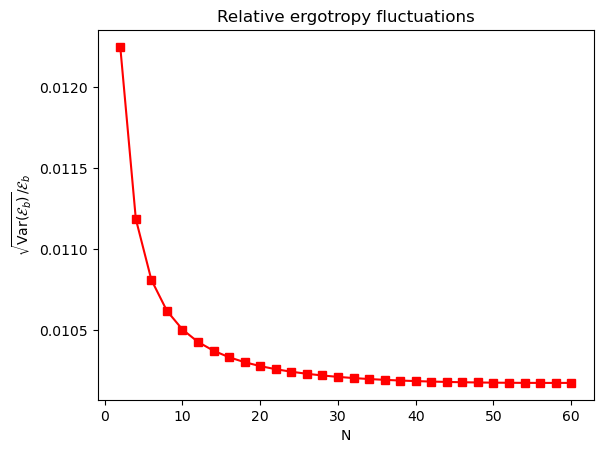

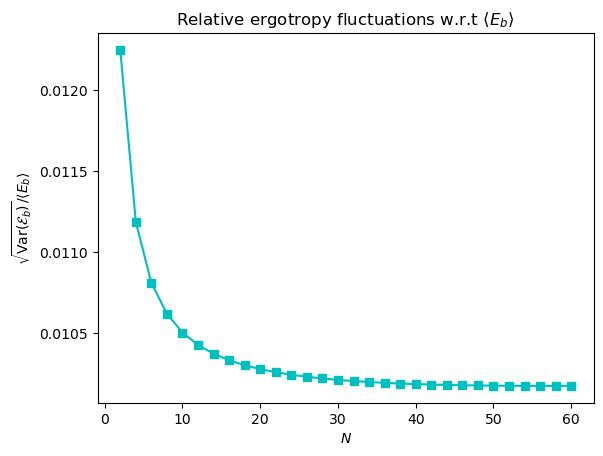

In [42]:
######################################################
# Plot fluctuations as a function of g for different N 
######################################################

for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={F_ratio[idx]:.6f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.6f}")


plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.show()

##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()